# Linear Regression

Predict calories burned from exercise duration using gradient descent, implemented purely with NumPy (no sklearn).

DATASET `calories.csv` 15,000 rows with features: Age, Height, Weight, Duration, Heart_Rate, Body_Temp  target: Calories

Model: `y_pred = w * X + b`
Loss: Mean Squared Error (MSE)
Optimization: Gradient Descent

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Load & Explore Data

In [2]:
df = pd.read_csv('calories.csv')
print(df.shape)
df.head()

(15000, 9)


,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [3]:
df.describe()

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


## 2. Prepare Features

`Duration` is the strongest single predictor of `Calories` — longer workouts burn more calories.

In [4]:
X = df['Duration'].values.reshape(-1, 1)  # feature
y = df['Calories'].values.reshape(-1, 1)  # target

# Normalize X — brings values to mean=0, std=1
# Why? Gradient descent converges faster and more stably on normalized inputs
X_norm = (X - X.mean()) / X.std()

print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"Duration range: {X.min():.1f} to {X.max():.1f} minutes")
print(f"Calories range: {y.min():.1f} to {y.max():.1f}")

X shape: (15000, 1), y shape: (15000, 1)
Duration range: 1.0 to 30.0 minutes
Calories range: 1.0 to 314.0


## 3. Initialize Parameters

In [5]:
np.random.seed(42)
w = np.random.randn(1)  # weight (slope)
b = np.random.randn(1)  # bias (intercept)

learning_rate = 0.01
n_iterations = 1000

print(f"Initial w: {w[0]:.4f}, b: {b[0]:.4f}")

Initial w: 0.4967, b: -0.1383


## 4. Gradient Descent

**Forward pass:** compute prediction and loss  
**Backward pass:** compute gradients dw and db  
**Update:** move w and b opposite to gradient (downhill)

```
dw = (2/n) * X.T @ (y_pred - y)   ← how much loss changes w.r.t. w
db = (2/n) * sum(y_pred - y)       ← how much loss changes w.r.t. b
```

In [8]:
losses = []

for i in range(n_iterations):
    # Forward pass
    y_pred = w * X_norm + b
    error = y_pred - y
    loss = (error ** 2).mean()  # MSE
    losses.append(loss)

    # Gradients
    dw = (2 / len(X_norm)) * np.dot(X_norm.T, error).squeeze()
    db = (2 / len(X_norm)) * np.sum(error)

    # Parameter update
    w -= learning_rate * dw
    b -= learning_rate * db

print(f"Final parameters: w={w[0]:.2f}, b={b[0]:.2f}")
print(f"Final MSE:  {loss:.2f}")
print(f"Final RMSE: {np.sqrt(loss):.2f} calories")

Final parameters: w=59.67, b=89.54
Final MSE:  340.02
Final RMSE: 18.44 calories


## 5. Visualize Results

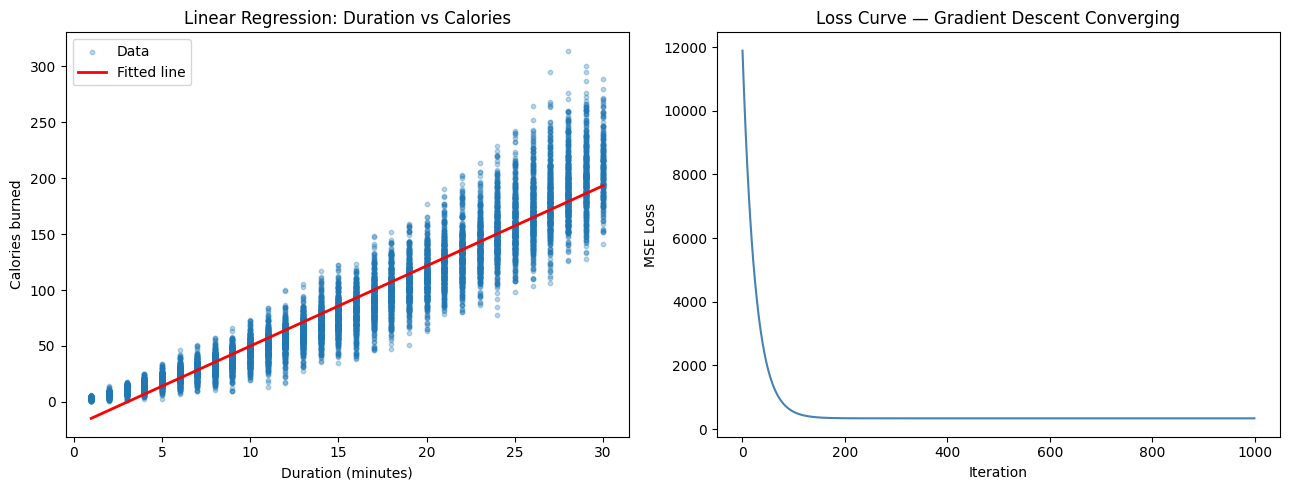

Plot saved as regression_output.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1 — Regression fit
axes[0].scatter(X, y, alpha=0.3, s=10, label='Data')
x_line_norm = np.linspace(X_norm.min(), X_norm.max(), 100).reshape(-1, 1)
y_line = w * x_line_norm + b
x_line_orig = x_line_norm * X.std() + X.mean()  # denormalize for x-axis
axes[0].plot(x_line_orig, y_line, color='red', linewidth=2, label='Fitted line')
axes[0].set_xlabel('Duration (minutes)')
axes[0].set_ylabel('Calories burned')
axes[0].set_title('Linear Regression: Duration vs Calories')
axes[0].legend()

# Plot 2 — Loss curve
axes[1].plot(losses, color='steelblue')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('MSE Loss')
axes[1].set_title('Loss Curve — Gradient Descent Converging')

plt.tight_layout()
plt.savefig('regression_output.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as regression_output.png")